In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
from langchain_groq import ChatGroq
# model=ChatGroq(model="qwen/qwen3.6-27b")
model=ChatGroq(model="openai/gpt-oss-120b")
# print(model)
# print("hello world")

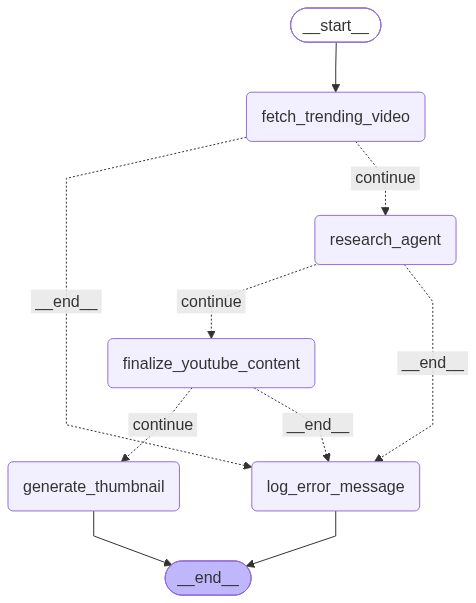

In [6]:
from langgraph.graph import StateGraph, START,END
from IPython.display import display, Image
from graph.schemas import State
from graph.nodes import fetch_trending_video,research_agent,finalize_youtube_content,generate_thumbnail,check_pipeline_status,log_error_message
builder=StateGraph(State)

builder.add_node("fetch_trending_video",fetch_trending_video)
builder.add_node("research_agent",lambda state: research_agent(state,model))
builder.add_node("finalize_youtube_content",lambda state:finalize_youtube_content(state,model))
builder.add_node("generate_thumbnail",generate_thumbnail)
builder.add_node("log_error_message",log_error_message)

builder.add_edge(START, "fetch_trending_video")
builder.add_conditional_edges("fetch_trending_video",check_pipeline_status,{"continue":"research_agent",END:"log_error_message"})
# builder.add_edge("fetch_trending_video","research_agent")
# builder.add_edge("research_agent","finalize_youtube_content")
builder.add_conditional_edges("research_agent",check_pipeline_status,{"continue":"finalize_youtube_content",END:"log_error_message"})
# builder.add_edge("finalize_youtube_content","generate_thumbnail")
builder.add_conditional_edges("finalize_youtube_content",check_pipeline_status,{"continue":"generate_thumbnail",END:"log_error_message"})
builder.add_edge("generate_thumbnail",END)
builder.add_edge("log_error_message",END)
recommendation_graph=builder.compile()
display(Image(recommendation_graph.get_graph().draw_mermaid_png()))

In [6]:
res = recommendation_graph.invoke(
    {"video_id": "abcd"},
    {"recursion_limit": 10}
)

fetch trending video node called
result of fetch trending vide node: {'title': 'US Iran War: ईरान पर अमेरिका की ताबड़तोड़ कार्रवाई! ट्रंप बोले- रडार और नौसैनिक ढांचा तबाह | AajTak', 'description': 'ईरान और अमेरिका के बीच तनाव लगातार बढ़ता जा रहा है। अमेरिकी राष्ट्रपति डोनाल्ड ट्रंप ने दावा किया है कि अमेरिकी सेना ने ईरान के रडार और नौसैनिक ढांचे पर बेहद भारी हमले किए हैं। वहीं ईरान की ओर से अमेरिकी हमलों में एक शादी समारोह को निशाना बनाए जाने और बड़ी संख्या में लोगों के हताहत होने का दावा किया गया है।\n\n    इस बीच ईरान ने अमेरिकी MQ-9 रीपर ड्रोन को मार गिराने का दावा किया है। आर्थिक मोर्चे पर भी दबाव बढ़ रहा है, जबकि SCO सम्मेलन के दौरान पीएम मोदी और ईरानी राष्ट्रपति मसूद पेज़ेश्कियान की मुलाकात के बाद अमेरिका की ओर से ईरान की आर्थिक मदद या प्रतिबंधों को दरकिनार करने वाले देशों को चेतावनी दी गई है। आखिर ईरान-अमेरिका की इस जंग का अगला मोड़ क्या होगा? \n    ', 'channelTitle': 'Aajtak', 'tags': ['usiranwar', 'usattack ', 'trump ', 'atwebvideos ', 'aajtak  ', 'aajtakdigital', 'tvchunks']}

KeyError: 'status'

In [ ]:
res["final_video_package"]

[{'title': 'US‑Iran ‘Heavy’ Attack 2026: Wedding Missile, Drone Down, Hormuz',
  'description': 'If you thought the latest US‑Iran clash was just another headline, discover how a single missile over a wedding, a downed drone, and soaring oil prices could reshape global trade and spark a new Cold‑War flashpoint.\nWe break down the ‘very heavy’ attack, the tragic wedding strike, the MQ‑9 Reaper shoot‑down, and what it means for the Strait of Hormuz and your wallet.\n\n00:00 – Introduction & Hook\n01:45 – What is a “Very Heavy” US attack?\n03:30 – The wedding missile: human cost & media impact\n05:20 – Iran’s MQ‑9 Reaper downed: tactics & implications\n07:10 – Ripple effects on the Strait of Hormuz\n09:00 – Global oil price surge & market reaction\n11:15 – Diplomatic moves: India, China, Russia & the SCO\n13:40 – What this escalation means for everyday viewers\n15:00 – Key takeaways & future outlook\n\nStay informed and subscribe for deeper geopolitical breakdowns.\n\n#USIranConflict #Str